
 LOADING IMDB CSV DATASET 

 DATASET LOADED SUCCESSFULLY 

First 5 Rows:

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

 DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Columns:

Index(['review', 'sentiment'], dtype='object')

 DATASET SHAPES 
Reviews : (50000,)
Labels  : (50000,)

 LABEL ENCODING COMPLETED 

Classes:

['negative' 'positive']

 TEXT VECTORIZATION COMPLETED 
Vectorized 

C:\Users\rohit\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 MODEL COMPILED SUCCESSFULLY 

 MODEL TRAINING STARTED 
Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.8604 - loss: 0.3216 - val_accuracy: 0.8857 - val_loss: 0.2765
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.9350 - loss: 0.1688 - val_accuracy: 0.8806 - val_loss: 0.3318
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 34s 34ms/step - accuracy: 0.9817 - loss: 0.0534 - val_accuracy: 0.8771 - val_loss: 0.4398
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.9967 - loss: 0.0109 - val_accuracy: 0.8756 - val_loss: 0.7798

 MODEL EVALUATION 
Test Loss     : 0.2676
Test Accuracy : 88.96 %

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4961
           1       0.89      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     100

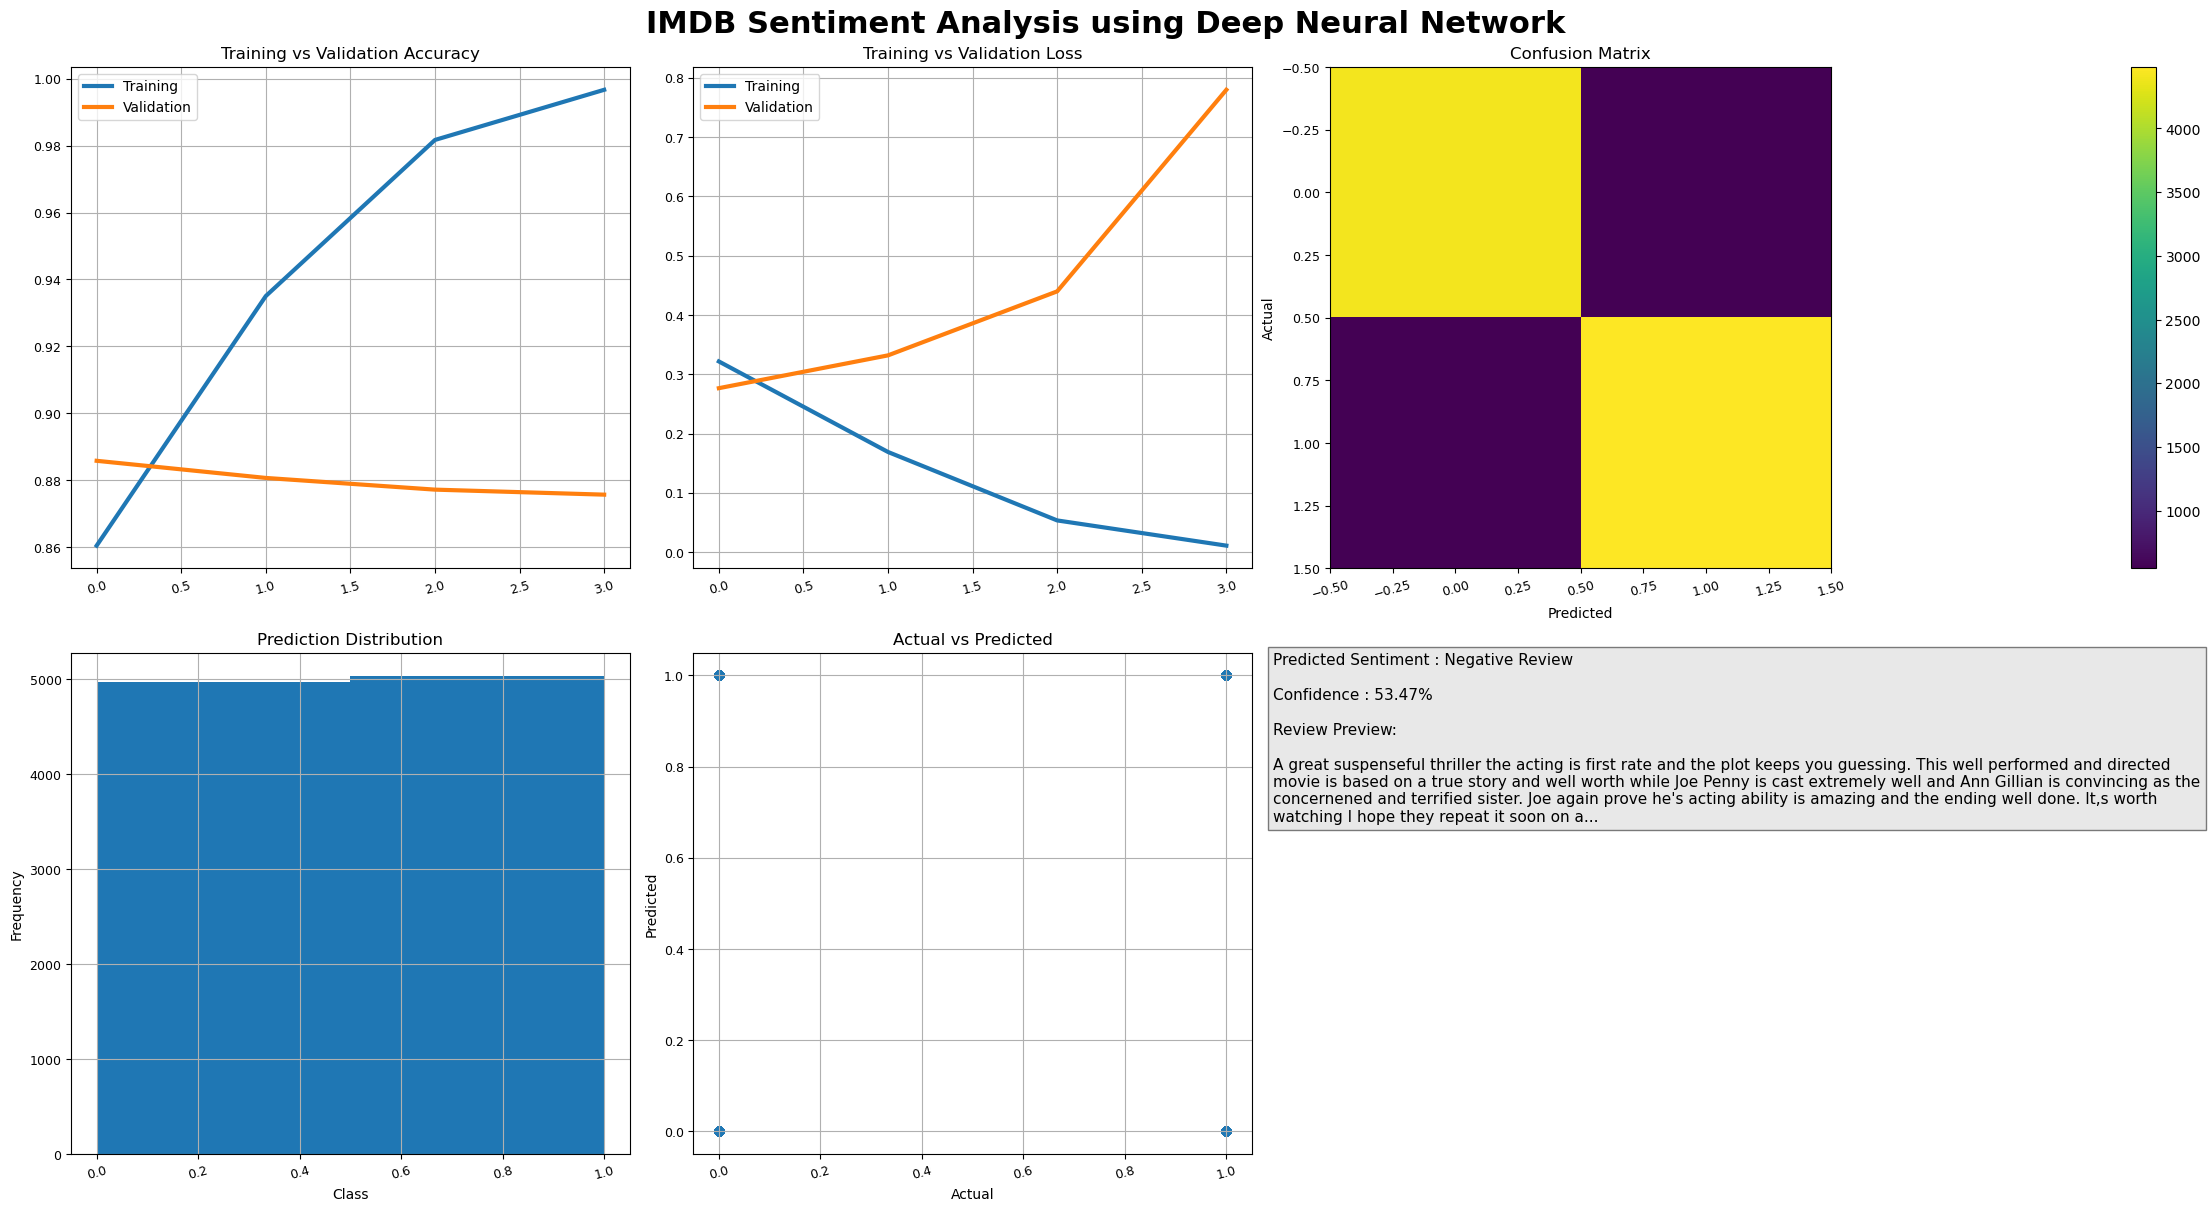


 FINAL ACCURACY 
Accuracy Score : 88.96 %

 MODEL SAVED SUCCESSFULLY 

 PROGRAM EXECUTED SUCCESSFULLY 


In [1]:
# =========================================================
# Binary Classification using Deep Neural Network
# IMDB Movie Review Sentiment Analysis
# FULL FINAL UPDATED CSV VERSION
# JUPYTER NOTEBOOK VERSION
# =========================================================

# =========================================================
# FEATURES
# =========================================================
#
# ✔ Local CSV Dataset Loading
# ✔ IMDB Review Classification
# ✔ Positive / Negative Detection
# ✔ Deep Neural Network
# ✔ Text Vectorization
# ✔ Random Review Prediction
# ✔ Confidence Score
# ✔ All Graphs in ONE Window
# ✔ Better Visualization
# ✔ No Overlapping
# ✔ Jupyter Notebook Compatible
#
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score
)

# =========================================================
# 2. LOAD IMDB CSV DATASET
# =========================================================

dataset_path = r"C:\Users\rohit\DL\DL\Binary_classification\dataset\IMDB\Dataset.csv"

print("\n====================================")
print(" LOADING IMDB CSV DATASET ")
print("====================================")

# ---------------------------------------------------------
# LOAD CSV
# ---------------------------------------------------------

data = pd.read_csv(dataset_path)

print("\n====================================")
print(" DATASET LOADED SUCCESSFULLY ")
print("====================================")

print("\nFirst 5 Rows:\n")

print(data.head())

print("\n====================================")
print(" DATASET INFO ")
print("====================================")

print(data.info())

# =========================================================
# 3. CHECK REQUIRED COLUMNS
# =========================================================

print("\nColumns:\n")

print(data.columns)

# =========================================================
# 4. REMOVE NULL VALUES
# =========================================================

data = data.dropna()

# =========================================================
# 5. FEATURES AND TARGET
# =========================================================

# ---------------------------------------------------------
# REVIEW TEXT
# ---------------------------------------------------------

X = data['review']

# ---------------------------------------------------------
# SENTIMENT LABEL
# ---------------------------------------------------------

y = data['sentiment']

print("\n====================================")
print(" DATASET SHAPES ")
print("====================================")

print("Reviews :", X.shape)
print("Labels  :", y.shape)

# =========================================================
# 6. LABEL ENCODING
# =========================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("\n====================================")
print(" LABEL ENCODING COMPLETED ")
print("====================================")

print("\nClasses:\n")

print(encoder.classes_)

# =========================================================
# 7. TEXT VECTORIZATION
# =========================================================

vectorizer = TfidfVectorizer(

    max_features=10000,

    stop_words='english'
)

X = vectorizer.fit_transform(X)

print("\n====================================")
print(" TEXT VECTORIZATION COMPLETED ")
print("====================================")

print("Vectorized Shape :", X.shape)

# =========================================================
# 8. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

print("\n====================================")
print(" DATASET SPLIT COMPLETED ")
print("====================================")

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# =========================================================
# 9. CONVERT SPARSE MATRIX TO ARRAY
# =========================================================

X_train = X_train.toarray()

X_test = X_test.toarray()

# =========================================================
# 10. BUILD DEEP NEURAL NETWORK
# =========================================================

model = keras.Sequential([

    # -----------------------------------------------------
    # INPUT LAYER
    # -----------------------------------------------------

    layers.Dense(

        512,

        activation='relu',

        input_shape=(X_train.shape[1],)
    ),

    layers.Dropout(0.3),

    # -----------------------------------------------------
    # HIDDEN LAYER 1
    # -----------------------------------------------------

    layers.Dense(

        256,

        activation='relu'
    ),

    layers.Dropout(0.3),

    # -----------------------------------------------------
    # HIDDEN LAYER 2
    # -----------------------------------------------------

    layers.Dense(

        128,

        activation='relu'
    ),

    layers.Dropout(0.2),

    # -----------------------------------------------------
    # HIDDEN LAYER 3
    # -----------------------------------------------------

    layers.Dense(

        64,

        activation='relu'
    ),

    # -----------------------------------------------------
    # OUTPUT LAYER
    # -----------------------------------------------------

    layers.Dense(

        1,

        activation='sigmoid'
    )
])

# =========================================================
# 11. COMPILE MODEL
# =========================================================

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

print("\n====================================")
print(" MODEL COMPILED SUCCESSFULLY ")
print("====================================")

# =========================================================
# 12. EARLY STOPPING
# =========================================================

early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True
)

# =========================================================
# 13. TRAIN MODEL
# =========================================================

print("\n====================================")
print(" MODEL TRAINING STARTED ")
print("====================================")

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

# =========================================================
# 14. EVALUATE MODEL
# =========================================================

loss, accuracy = model.evaluate(

    X_test,
    y_test,

    verbose=0
)

print("\n====================================")
print(" MODEL EVALUATION ")
print("====================================")

print("Test Loss     :", round(loss, 4))
print("Test Accuracy :", round(accuracy * 100, 2), "%")

# =========================================================
# 15. PREDICTIONS
# =========================================================

predictions = model.predict(
    X_test,
    verbose=0
)

predicted_classes = (

    predictions > 0.5
).astype("int32")

# =========================================================
# 16. CLASSIFICATION REPORT
# =========================================================

print("\n====================================")
print(" CLASSIFICATION REPORT ")
print("====================================")

print(

    classification_report(

        y_test,

        predicted_classes
    )
)

# =========================================================
# 17. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(

    y_test,

    predicted_classes
)

# =========================================================
# 18. RANDOM REVIEW PREDICTION
# =========================================================

random_index = random.randint(
    0,
    len(X_test)-1
)

sample = X_test[random_index].reshape(1, -1)

prediction = model.predict(
    sample,
    verbose=0
)[0][0]

# =========================================================
# SENTIMENT DETECTION
# =========================================================

if prediction > 0.5:

    sentiment = "Positive Review"

    confidence = prediction * 100

else:

    sentiment = "Negative Review"

    confidence = (1 - prediction) * 100

# =========================================================
# GET REVIEW TEXT
# =========================================================

original_review = data['review'].iloc[random_index]

# Limit review size
original_review = original_review[:600]

# =========================================================
# 19. CREATE ALL OUTPUTS TOGETHER
# =========================================================

fig, axes = plt.subplots(

    2,
    3,

    figsize=(22, 12),

    constrained_layout=True
)

# =========================================================
# MAIN TITLE
# =========================================================

fig.suptitle(

    "IMDB Sentiment Analysis using Deep Neural Network",

    fontsize=22,

    fontweight='bold'
)

# =========================================================
# GRAPH 1 : ACCURACY GRAPH
# =========================================================

axes[0,0].plot(

    history.history['accuracy'],

    linewidth=3
)

axes[0,0].plot(

    history.history['val_accuracy'],

    linewidth=3
)

axes[0,0].set_title(
    "Training vs Validation Accuracy"
)

axes[0,0].legend([
    "Training",
    "Validation"
])

axes[0,0].grid(True)

# =========================================================
# GRAPH 2 : LOSS GRAPH
# =========================================================

axes[0,1].plot(

    history.history['loss'],

    linewidth=3
)

axes[0,1].plot(

    history.history['val_loss'],

    linewidth=3
)

axes[0,1].set_title(
    "Training vs Validation Loss"
)

axes[0,1].legend([
    "Training",
    "Validation"
])

axes[0,1].grid(True)

# =========================================================
# GRAPH 3 : CONFUSION MATRIX
# =========================================================

im = axes[0,2].imshow(cm)

axes[0,2].set_title(
    "Confusion Matrix"
)

axes[0,2].set_xlabel("Predicted")
axes[0,2].set_ylabel("Actual")

fig.colorbar(
    im,
    ax=axes[0,2]
)

# =========================================================
# GRAPH 4 : PREDICTION DISTRIBUTION
# =========================================================

axes[1,0].hist(

    predicted_classes,

    bins=2
)

axes[1,0].set_title(
    "Prediction Distribution"
)

axes[1,0].set_xlabel("Class")
axes[1,0].set_ylabel("Frequency")

axes[1,0].grid(True)

# =========================================================
# GRAPH 5 : ACTUAL VS PREDICTED
# =========================================================

axes[1,1].scatter(

    y_test,

    predicted_classes,

    alpha=0.5
)

axes[1,1].set_title(
    "Actual vs Predicted"
)

axes[1,1].set_xlabel("Actual")
axes[1,1].set_ylabel("Predicted")

axes[1,1].grid(True)

# =========================================================
# GRAPH 6 : RANDOM REVIEW PREDICTION
# =========================================================

axes[1,2].axis("off")

review_text = (

    f"Predicted Sentiment : {sentiment}\n\n"

    f"Confidence : {confidence:.2f}%\n\n"

    f"Review Preview:\n\n"

    f"{original_review[:400]}..."
)

axes[1,2].text(

    0,
    1,

    review_text,

    fontsize=11,

    verticalalignment='top',

    wrap=True,

    bbox=dict(
        facecolor='lightgray',
        alpha=0.5
    )
)

# =========================================================
# FIX OVERLAPPING
# =========================================================

for ax in axes.flat:

    ax.tick_params(

        axis='x',

        rotation=15,

        labelsize=9
    )

    ax.tick_params(

        axis='y',

        labelsize=9
    )

# =========================================================
# SHOW EVERYTHING
# =========================================================

plt.show()

# =========================================================
# 20. FINAL ACCURACY
# =========================================================

final_accuracy = accuracy_score(

    y_test,

    predicted_classes
)

print("\n====================================")
print(" FINAL ACCURACY ")
print("====================================")

print(
    "Accuracy Score :",
    round(final_accuracy * 100, 2),
    "%"
)

# =========================================================
# 21. SAVE MODEL
# =========================================================

model.save(
    "imdb_sentiment_dnn_model.h5"
)

print("\n====================================")
print(" MODEL SAVED SUCCESSFULLY ")
print("====================================")

# =========================================================
# 22. PROGRAM FINISHED
# =========================================================

print("\n====================================")
print(" PROGRAM EXECUTED SUCCESSFULLY ")
print("====================================")